# Evaluate CNN, ViT, and Hybrid Models

This notebook evaluates the three trained models on the test dataset and provides comprehensive metrics including accuracy, confusion matrix, and per-class performance.


In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import transforms
from PIL import Image
import numpy as np
from pathlib import Path
import pickle
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import sys

# Import tqdm with Jupyter notebook support
try:
    from tqdm.auto import tqdm
except ImportError:
    from tqdm import tqdm
    print("Note: Install tqdm for better progress bars: pip install tqdm")

# Check PyTorch and CUDA setup
print("=" * 60)
print("Evaluation Setup")
print("=" * 60)
print(f"PyTorch Version: {torch.__version__}")

# Set device and check GPU availability
if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"\n✅ CUDA is available!")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
    gpu_props = torch.cuda.get_device_properties(0)
    print(f"GPU Memory: {gpu_props.total_memory / 1024**3:.2f} GB")
    torch.cuda.empty_cache()
    print(f"\n🚀 Ready for GPU evaluation on {torch.cuda.get_device_name(0)}!")
else:
    device = torch.device('cpu')
    print(f"\n⚠️ CUDA is not available. Using CPU (evaluation will be slower).")

print(f"\nUsing device: {device}")
print("=" * 60)

# Set paths
DATA_DIR = Path('../data/devanagari')
TEST_DIR = DATA_DIR / 'Test'
MODELS_DIR = Path('../models')

# Check if models directory exists
if not MODELS_DIR.exists():
    print(f"\n❌ Error: Models directory not found at {MODELS_DIR}")
    print("Please run the training notebook first to generate models.")
else:
    print(f"\n✅ Models directory found: {MODELS_DIR}")

# Load class mappings
try:
    with open('../utils/class_mappings.pkl', 'rb') as f:
        mappings = pickle.load(f)
        class_to_idx = mappings['class_to_idx']
        idx_to_class = mappings['idx_to_class']
        classes = mappings['classes']
    num_classes = len(classes)
    print(f"✅ Loaded class mappings: {num_classes} classes")
except FileNotFoundError:
    print("\n❌ Error: Class mappings file not found!")
    print("Please run the data exploration notebook first.")
    raise


Evaluation Setup
PyTorch Version: 2.9.1+cpu

⚠️ CUDA is not available. Using CPU (evaluation will be slower).

Using device: cpu

✅ Models directory found: ..\models
✅ Loaded class mappings: 46 classes


In [2]:
# Redefine models (copy from training notebook)
# CNN Model
class CNNModel(nn.Module):
    def __init__(self, num_classes=46):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(256)
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(256 * 2 * 2, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.relu = nn.ReLU()
    def forward(self, x):
        x = self.pool(self.relu(self.bn1(self.conv1(x))))
        x = self.pool(self.relu(self.bn2(self.conv2(x))))
        x = self.pool(self.relu(self.bn3(self.conv3(x))))
        x = self.pool(self.relu(self.bn4(self.conv4(x))))
        x = x.view(x.size(0), -1)
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

# ViT components
class PatchEmbedding(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128):
        super().__init__()
        self.img_size = img_size
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Conv2d(in_channels, embed_dim, kernel_size=patch_size, stride=patch_size)
    def forward(self, x):
        x = self.proj(x)
        B, C, H, W = x.shape
        x = x.flatten(2).transpose(1, 2)
        return x

class MultiHeadAttention(nn.Module):
    def __init__(self, embed_dim, num_heads):
        super().__init__()
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.head_dim = embed_dim // num_heads
        self.qkv = nn.Linear(embed_dim, embed_dim * 3)
        self.proj = nn.Linear(embed_dim, embed_dim)
    def forward(self, x):
        B, N, C = x.shape
        qkv = self.qkv(x).reshape(B, N, 3, self.num_heads, self.head_dim).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]
        attn = (q @ k.transpose(-2, -1)) * (self.head_dim ** -0.5)
        attn = attn.softmax(dim=-1)
        x = (attn @ v).transpose(1, 2).reshape(B, N, C)
        x = self.proj(x)
        return x

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, mlp_ratio=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(embed_dim)
        self.attn = MultiHeadAttention(embed_dim, num_heads)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * mlp_ratio),
            nn.GELU(),
            nn.Dropout(0.1),
            nn.Linear(embed_dim * mlp_ratio, embed_dim),
            nn.Dropout(0.1)
        )
    def forward(self, x):
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class ViTModel(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_channels=3, embed_dim=128, 
                 num_heads=4, num_layers=4, num_classes=46):
        super().__init__()
        self.patch_embed = PatchEmbedding(img_size, patch_size, in_channels, embed_dim)
        num_patches = self.patch_embed.n_patches
        self.cls_token = nn.Parameter(torch.randn(1, 1, embed_dim))
        self.pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, embed_dim))
        self.dropout = nn.Dropout(0.1)
        self.blocks = nn.ModuleList([TransformerBlock(embed_dim, num_heads) for _ in range(num_layers)])
        self.norm = nn.LayerNorm(embed_dim)
        self.head = nn.Linear(embed_dim, num_classes)
    def forward(self, x):
        B = x.shape[0]
        x = self.patch_embed(x)
        cls_tokens = self.cls_token.expand(B, -1, -1)
        x = torch.cat((cls_tokens, x), dim=1)
        x = x + self.pos_embed
        x = self.dropout(x)
        for block in self.blocks:
            x = block(x)
        x = self.norm(x)
        cls_token_final = x[:, 0]
        return self.head(cls_token_final)

class HybridModel(nn.Module):
    def __init__(self, num_classes=46):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
        )
        self.vit_patch_embed = PatchEmbedding(img_size=32, patch_size=4, in_channels=3, embed_dim=64)
        num_patches = self.vit_patch_embed.n_patches
        self.vit_cls_token = nn.Parameter(torch.randn(1, 1, 64))
        self.vit_pos_embed = nn.Parameter(torch.randn(1, num_patches + 1, 64))
        self.vit_blocks = nn.ModuleList([TransformerBlock(embed_dim=64, num_heads=2) for _ in range(2)])
        self.vit_norm = nn.LayerNorm(64)
        self.fusion = nn.Sequential(
            nn.Linear(128 * 8 * 8 + 64, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    def forward(self, x):
        cnn_out = self.cnn(x)
        cnn_out = cnn_out.view(cnn_out.size(0), -1)
        vit_out = self.vit_patch_embed(x)
        B = vit_out.shape[0]
        cls_tokens = self.vit_cls_token.expand(B, -1, -1)
        vit_out = torch.cat((cls_tokens, vit_out), dim=1)
        vit_out = vit_out + self.vit_pos_embed
        for block in self.vit_blocks:
            vit_out = block(vit_out)
        vit_out = self.vit_norm(vit_out)
        vit_out = vit_out[:, 0]
        combined = torch.cat([cnn_out, vit_out], dim=1)
        return self.fusion(combined)

print("Models defined")


Models defined


In [3]:
# Dataset class (same as training)
class DevanagariDataset:
    def __init__(self, data_dir, class_to_idx, transform=None):
        self.data_dir = Path(data_dir)
        self.transform = transform
        self.class_to_idx = class_to_idx
        self.images = []
        self.labels = []
        for cls_name in class_to_idx.keys():
            cls_dir = self.data_dir / cls_name
            if cls_dir.exists():
                for img_path in cls_dir.glob('*.png'):
                    self.images.append(img_path)
                    self.labels.append(class_to_idx[cls_name])
    def __len__(self):
        return len(self.images)
    def __getitem__(self, idx):
        img_path = self.images[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]
        if self.transform:
            image = self.transform(image)
        return image, label

# Test transform
test_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# Create test dataset
test_dataset = DevanagariDataset(TEST_DIR, class_to_idx, transform=test_transform)

# Optimize DataLoader for GPU evaluation
if torch.cuda.is_available():
    batch_size = 128  # Larger batch size for GPU
    pin_memory = True
    num_workers = 0  # Windows compatibility
    print(f"🚀 GPU detected - Using optimized settings:")
    print(f"   Batch size: {batch_size} (increased for GPU)")
else:
    batch_size = 64
    pin_memory = False
    num_workers = 0
    print(f"💻 CPU mode - Using standard settings:")
    print(f"   Batch size: {batch_size}")

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False, 
    num_workers=num_workers,
    pin_memory=pin_memory
)

print(f"\n✅ Test dataset loaded:")
print(f"   Test samples: {len(test_dataset)}")
print(f"   Number of batches: {len(test_loader)}")
print(f"   Batch size: {batch_size}")


💻 CPU mode - Using standard settings:
   Batch size: 64

✅ Test dataset loaded:
   Test samples: 13800
   Number of batches: 216
   Batch size: 64


In [4]:
# Evaluation function with GPU optimization
def evaluate_model(model, test_loader, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    correct = 0
    total = 0
    
    # Use mixed precision for faster GPU evaluation
    use_amp = torch.cuda.is_available()
    
    with torch.no_grad():
        pbar = tqdm(test_loader, desc=f'Evaluating {model_name}', 
                   unit='batch', ncols=120, file=sys.stdout)
        
        for batch_idx, (images, labels) in enumerate(pbar):
            # Move data to device (GPU if available)
            images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            
            # Use mixed precision if GPU is available
            if use_amp:
                with torch.cuda.amp.autocast():
                    outputs = model(images)
            else:
                outputs = model(images)
            
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            
            # Update progress bar
            current_acc = 100 * correct / total
            if torch.cuda.is_available():
                gpu_mem = torch.cuda.memory_allocated(0) / 1024**3
                pbar.set_postfix({
                    'acc': f'{current_acc:.2f}%',
                    'GPU_mem': f'{gpu_mem:.2f}GB',
                    'batch': f'{batch_idx+1}/{len(test_loader)}'
                })
            else:
                pbar.set_postfix({
                    'acc': f'{current_acc:.2f}%',
                    'batch': f'{batch_idx+1}/{len(test_loader)}'
                })
            sys.stdout.flush()
    
    accuracy = 100 * correct / total
    
    # Clear GPU cache
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    
    print(f'\n✅ {model_name} Evaluation Complete:')
    print(f'   Accuracy: {accuracy:.2f}%')
    print(f'   Correct: {correct}/{total}')
    
    return all_preds, all_labels, accuracy

# Load and evaluate models
models = {}
results = {}

# CNN Model
print("\n" + "="*60)
print("Loading and Evaluating CNN Model")
print("="*60)
try:
    cnn_model = CNNModel(num_classes=num_classes)
    cnn_model.load_state_dict(torch.load(MODELS_DIR / 'cnn_model.pth', map_location=device))
    cnn_model = cnn_model.to(device)
    cnn_model.eval()
    print("✅ CNN model loaded successfully")
    cnn_preds, cnn_labels, cnn_acc = evaluate_model(cnn_model, test_loader, 'CNN')
    results['CNN'] = {'preds': cnn_preds, 'labels': cnn_labels, 'accuracy': cnn_acc}
    models['CNN'] = cnn_model
except FileNotFoundError:
    print(f"❌ Error: CNN model not found at {MODELS_DIR / 'cnn_model.pth'}")
    print("Please run the training notebook first.")
    raise
except Exception as e:
    print(f"❌ Error loading CNN model: {e}")
    raise



Loading and Evaluating CNN Model
✅ CNN model loaded successfully


Evaluating CNN:   0%|                                                                        | 0/216 [00:00<?,…


✅ CNN Evaluation Complete:
   Accuracy: 97.28%
   Correct: 13425/13800


In [5]:
# ViT Model
print("\n" + "="*60)
print("Loading and Evaluating ViT Model")
print("="*60)
try:
    vit_model = ViTModel(num_classes=num_classes)
    vit_model.load_state_dict(torch.load(MODELS_DIR / 'vit_model.pth', map_location=device))
    vit_model = vit_model.to(device)
    vit_model.eval()
    print("✅ ViT model loaded successfully")
    vit_preds, vit_labels, vit_acc = evaluate_model(vit_model, test_loader, 'ViT')
    results['ViT'] = {'preds': vit_preds, 'labels': vit_labels, 'accuracy': vit_acc}
    models['ViT'] = vit_model
except FileNotFoundError:
    print(f"❌ Error: ViT model not found at {MODELS_DIR / 'vit_model.pth'}")
    print("Please run the training notebook first.")
    raise
except Exception as e:
    print(f"❌ Error loading ViT model: {e}")
    raise



Loading and Evaluating ViT Model
✅ ViT model loaded successfully


Evaluating ViT:   0%|                                                                        | 0/216 [00:00<?,…


✅ ViT Evaluation Complete:
   Accuracy: 87.32%
   Correct: 12050/13800


In [6]:
# Hybrid Model
print("\n" + "="*60)
print("Loading and Evaluating Hybrid Model")
print("="*60)
try:
    hybrid_model = HybridModel(num_classes=num_classes)
    hybrid_model.load_state_dict(torch.load(MODELS_DIR / 'hybrid_model.pth', map_location=device))
    hybrid_model = hybrid_model.to(device)
    hybrid_model.eval()
    print("✅ Hybrid model loaded successfully")
    hybrid_preds, hybrid_labels, hybrid_acc = evaluate_model(hybrid_model, test_loader, 'Hybrid')
    results['Hybrid'] = {'preds': hybrid_preds, 'labels': hybrid_labels, 'accuracy': hybrid_acc}
    models['Hybrid'] = hybrid_model
except FileNotFoundError:
    print(f"❌ Error: Hybrid model not found at {MODELS_DIR / 'hybrid_model.pth'}")
    print("Please run the training notebook first.")
    raise
except Exception as e:
    print(f"❌ Error loading Hybrid model: {e}")
    raise

print("\n" + "="*60)
print("✅ All Models Evaluated Successfully!")
print("="*60)



Loading and Evaluating Hybrid Model
✅ Hybrid model loaded successfully


Evaluating Hybrid:   0%|                                                                     | 0/216 [00:00<?,…


✅ Hybrid Evaluation Complete:
   Accuracy: 96.87%
   Correct: 13368/13800

✅ All Models Evaluated Successfully!



MODEL COMPARISON SUMMARY
Model           Accuracy        Status         
------------------------------------------------------------
CNN              97.28%       🏆 Best         
ViT              87.32%       ✓              
Hybrid           96.87%       ✓              

🏆 Best Model: CNN with 97.28% accuracy


C:\Users\khush\AppData\Local\Temp\ipykernel_22732\2081034995.py:40: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\khush\AppData\Local\Temp\ipykernel_22732\2081034995.py:41: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  plt.savefig('../models/accuracy_comparison.png', dpi=150, bbox_inches='tight')



💾 Accuracy comparison plot saved to ../models/accuracy_comparison.png


C:\Users\khush\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


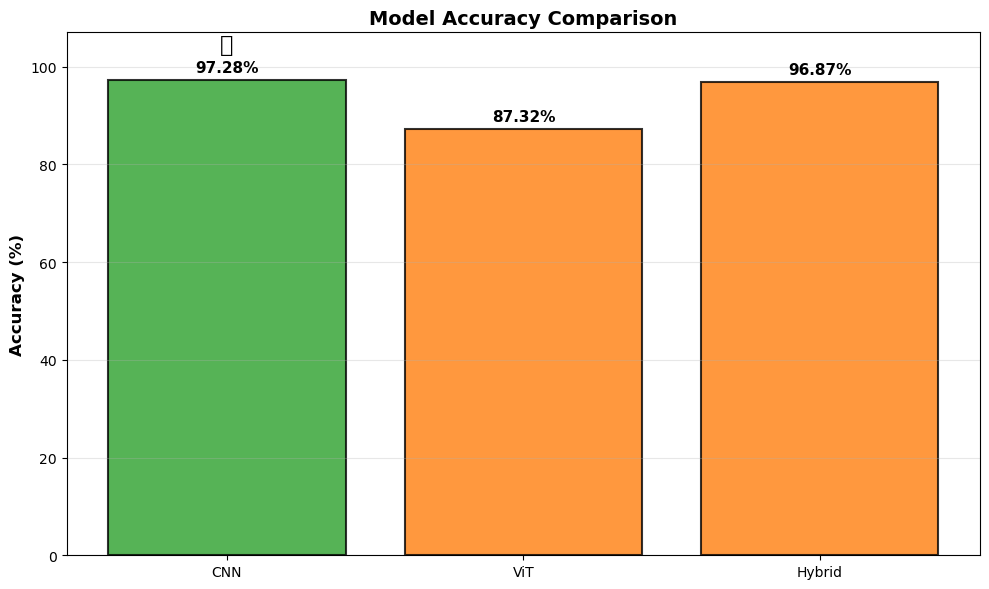

In [7]:
# Compare accuracies
print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(f"{'Model':<15} {'Accuracy':<15} {'Status':<15}")
print("-" * 60)

# Find best model
best_model = max(results.items(), key=lambda x: x[1]['accuracy'])
best_acc = best_model[1]['accuracy']

for model_name, result in results.items():
    status = "🏆 Best" if model_name == best_model[0] else "✓"
    print(f"{model_name:<15} {result['accuracy']:>6.2f}%       {status:<15}")

print("="*60)
print(f"\n🏆 Best Model: {best_model[0]} with {best_acc:.2f}% accuracy")

# Plot accuracy comparison
fig, ax = plt.subplots(figsize=(10, 6))
model_names = list(results.keys())
accuracies = [results[m]['accuracy'] for m in model_names]
colors = ['#2ca02c' if m == best_model[0] else '#1f77b4' if m == 'CNN' else '#ff7f0e' for m in model_names]
bars = ax.bar(model_names, accuracies, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)

ax.set_ylabel('Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
ax.set_ylim([0, max(accuracies) * 1.1])
ax.grid(True, alpha=0.3, axis='y')

# Add value labels on bars
for i, (bar, acc) in enumerate(zip(bars, accuracies)):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + max(accuracies) * 0.01,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=11, fontweight='bold')
    if model_names[i] == best_model[0]:
        ax.text(bar.get_x() + bar.get_width()/2., height + max(accuracies) * 0.05,
                '🏆', ha='center', va='bottom', fontsize=16)

plt.tight_layout()
plt.savefig('../models/accuracy_comparison.png', dpi=150, bbox_inches='tight')
print(f"\n💾 Accuracy comparison plot saved to ../models/accuracy_comparison.png")
plt.show()


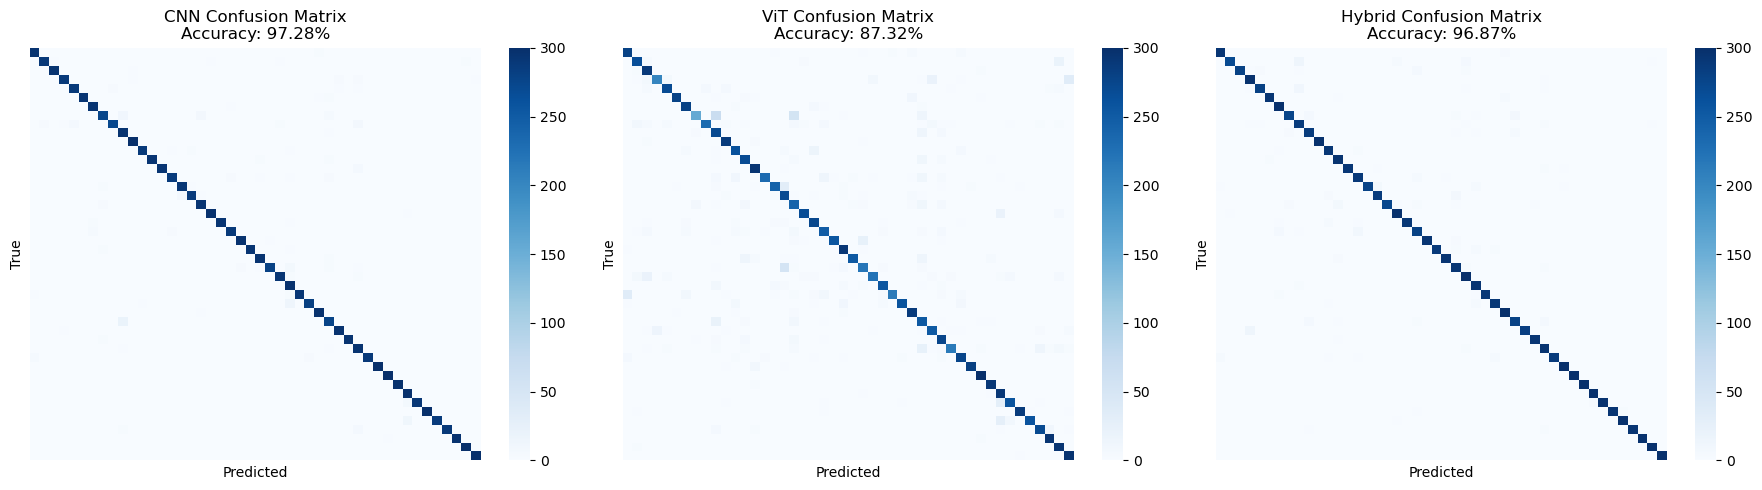

In [8]:
# Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (model_name, result) in enumerate(results.items()):
    cm = confusion_matrix(result['labels'], result['preds'])
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=False, yticklabels=False)
    axes[idx].set_title(f'{model_name} Confusion Matrix\nAccuracy: {result["accuracy"]:.2f}%')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('True')

plt.tight_layout()
plt.savefig('../models/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


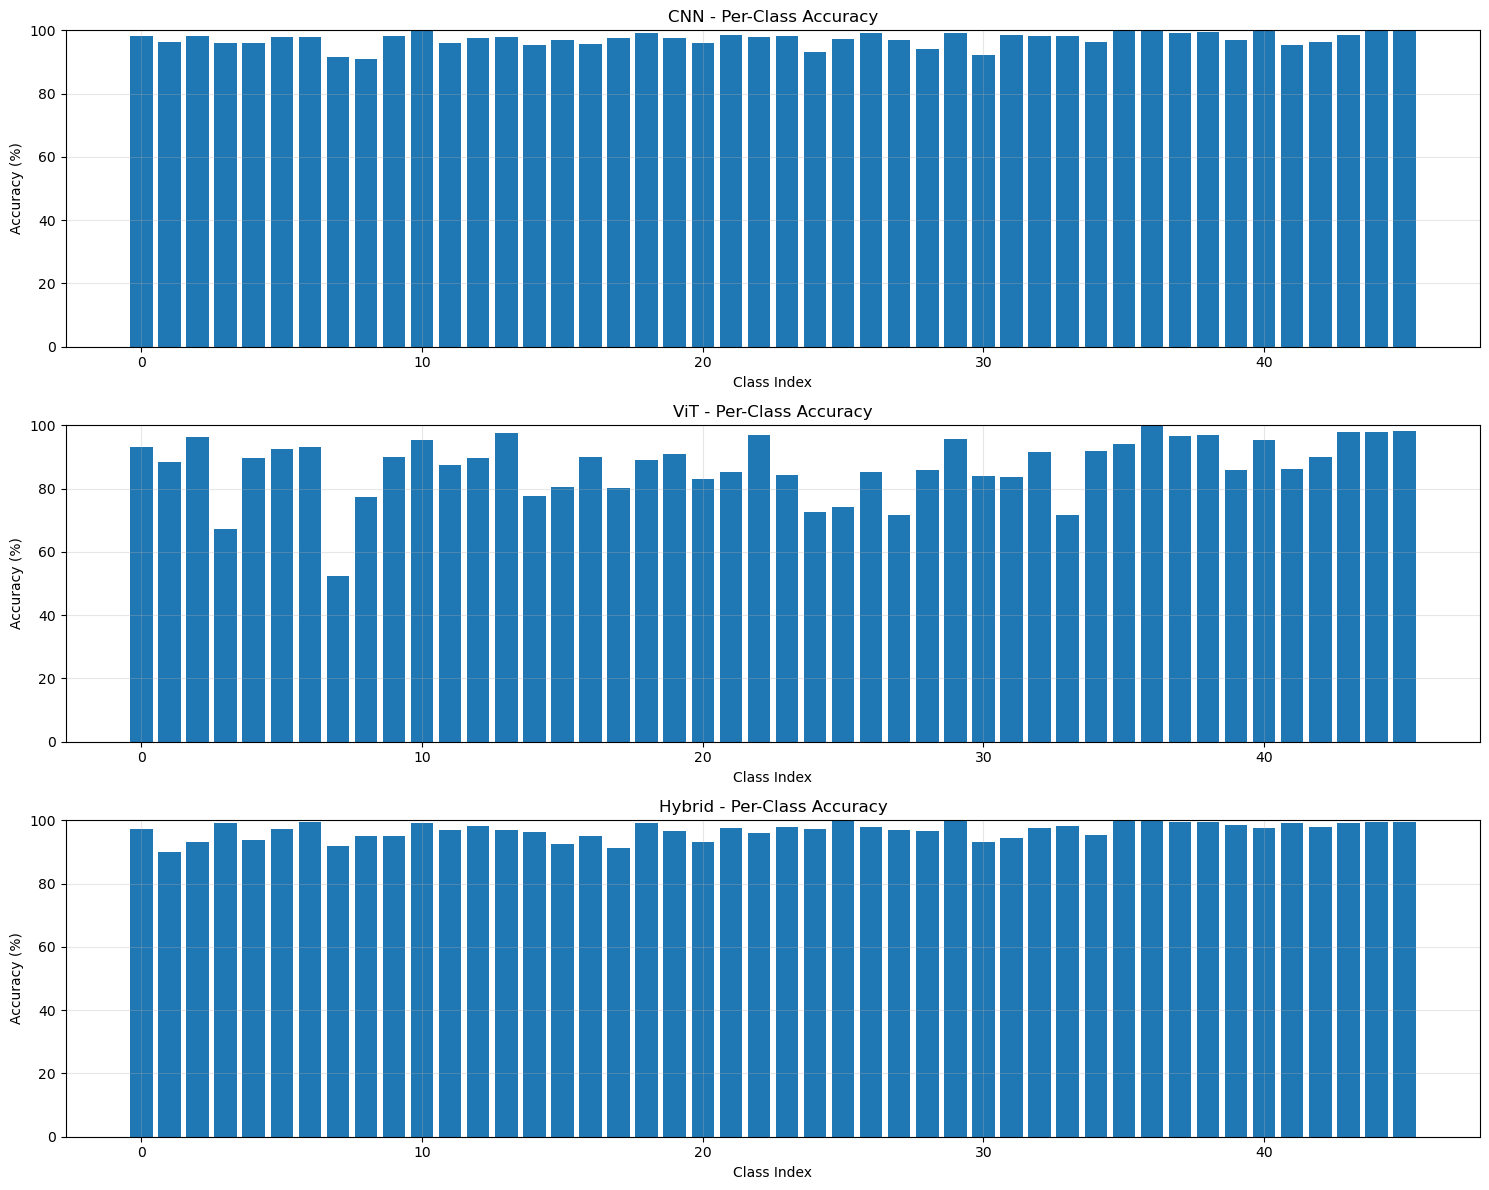

In [9]:












# Per-class accuracy
def get_per_class_accuracy(preds, labels, num_classes):
    class_correct = [0] * num_classes
    class_total = [0] * num_classes
    for p, l in zip(preds, labels):
        class_total[l] += 1
        if p == l:
            class_correct[l] += 1
    per_class_acc = [100 * class_correct[i] / class_total[i] if class_total[i] > 0 else 0 
                     for i in range(num_classes)]
    return per_class_acc

# Calculate per-class accuracies
fig, axes = plt.subplots(3, 1, figsize=(15, 12))
for idx, (model_name, result) in enumerate(results.items()):
    per_class_acc = get_per_class_accuracy(result['preds'], result['labels'], num_classes)
    axes[idx].bar(range(num_classes), per_class_acc)
    axes[idx].set_title(f'{model_name} - Per-Class Accuracy')
    axes[idx].set_xlabel('Class Index')
    axes[idx].set_ylabel('Accuracy (%)')
    axes[idx].set_ylim([0, 100])
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../models/per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()


In [10]:
# Classification reports
print("\n" + "="*60)
print("DETAILED CLASSIFICATION REPORTS")
print("="*60)

for model_name, result in results.items():
    print(f"\n{'='*60}")
    print(f"{model_name} Model - Detailed Report")
    print(f"{'='*60}")
    report = classification_report(
        result['labels'], 
        result['preds'], 
        target_names=[classes[i] for i in range(num_classes)],
        zero_division=0,
        output_dict=False
    )
    print(report)

print("\n" + "="*60)
print("✅ Evaluation completed successfully!")
print("="*60)
print(f"\n📊 Results saved to: ../models/")
print(f"   - accuracy_comparison.png")
print(f"   - confusion_matrices.png")
print(f"   - per_class_accuracy.png")
print("\n" + "="*60)



DETAILED CLASSIFICATION REPORTS

CNN Model - Detailed Report
                           precision    recall  f1-score   support

         character_10_yna       0.97      0.98      0.98       300
    character_11_taamatar       0.98      0.96      0.97       300
        character_12_thaa       0.99      0.98      0.98       300
         character_13_daa       0.98      0.96      0.97       300
        character_14_dhaa       0.98      0.96      0.97       300
        character_15_adna       1.00      0.98      0.99       300
      character_16_tabala       0.96      0.98      0.97       300
         character_17_tha       0.94      0.92      0.93       300
          character_18_da       0.98      0.91      0.94       300
         character_19_dha       0.89      0.98      0.93       300
           character_1_ka       0.98      1.00      0.99       300
          character_20_na       0.98      0.96      0.97       300
          character_21_pa       0.99      0.98      0.98       300